# 1. Data Collection through Web Scraping

## **Data Source**

The dataset for this project was collected from the official NBA statistics API:

**API Endpoint:**
`https://stats.nba.com/stats/leaguedashplayerstats`

Although this URL cannot be opened directly in a browser due to Cloudflare protection,
the API returns a valid JSON response when accessed programmatically with proper request headers.
This endpoint is publicly accessible and does not require authentication or login.

The API provides detailed player statistics for a selected NBA season, covering both basic and advanced metrics.

---

## **Scraping Method**

A custom Python script was used to download the dataset.
The script sends an HTTP GET request with browser-like headers, including:

- `User-Agent`
- `Accept`
- `Origin`
- `Referer`
- `Accept-Language`

These headers replicate normal browser behaviour, preventing the request from being blocked.

The API responds with a JSON structure containing:

- `resultSets` – a list of returned statistical tables
- `headers` – column names
- `rowSet` – data rows for each player

The script extracts the first table, converts it into a list of dictionaries, then saves it as a CSV.

---

## **Parameters Used**

The following query parameters were passed to the API:

| Parameter     | Value          | Description                         |
|---------------|----------------|-------------------------------------|
| `Season`      | 2025-26        | Selected NBA season                 |
| `SeasonType`  | Regular Season | Only regular season games           |
| `PerMode`     | PerGame        | Per-game player statistics          |

---

## **Variables Collected**

The API returns more than 60 variables.
Key examples include:

- `PLAYER_NAME` – player name
- `TEAM_NAME` – the player's team
- `PTS` – points per game
- `REB` – rebounds per game
- `AST` – assists per game
- `FGM`, `FGA`, `FG_PCT` – field goal statistics
- `3PM`, `3PA`, `3P_PCT` – three-point shooting
- `STL`, `BLK`, `TOV` – defensive metrics
- `PLUS_MINUS` – on-court impact
- `GP`, `MIN` – games played and minutes

This provides a rich dataset suitable for analysis and modelling.

---

## **Dataset Size**

After scraping, the dataset contains:

- **Rows:** X players
- **Columns:** Y statistical features

(Replace X and Y with actual values after loading the CSV.)

This satisfies the requirement of having at least **150 rows and 5 columns**.

---

## **Saving the Data**

The parsed JSON was converted into a tabular structure and stored as: nba_player_stats_2025-26_RegularSeason_PerGame.csv



# 2. Perform data preparation and cleaning

## 2.1 Data preparation Perform

---
### 2.1.1 Import necessary package:

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

---
### 2.1.2 Read the dataset crawled in the previous step

In [14]:
df = pd.read_csv(   "nba_player_stats_2025-26_RegularSeason_PerGame.csv",skiprows=1)

---
### 2.1.3 Show the dataset's information

In [15]:
df.shape

(490, 67)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 67 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              490 non-null    int64  
 1   PLAYER_NAME            490 non-null    object 
 2   NICKNAME               490 non-null    object 
 3   TEAM_ID                490 non-null    int64  
 4   TEAM_ABBREVIATION      490 non-null    object 
 5   AGE                    490 non-null    float64
 6   GP                     490 non-null    int64  
 7   W                      490 non-null    int64  
 8   L                      490 non-null    int64  
 9   W_PCT                  490 non-null    float64
 10  MIN                    490 non-null    float64
 11  FGM                    490 non-null    float64
 12  FGA                    490 non-null    float64
 13  FG_PCT                 490 non-null    float64
 14  FG3M                   490 non-null    float64
 15  FG3A  

In [17]:
df.dtypes

PLAYER_ID                 int64
PLAYER_NAME              object
NICKNAME                 object
TEAM_ID                   int64
TEAM_ABBREVIATION        object
                          ...  
NBA_FANTASY_PTS_RANK      int64
DD2_RANK                  int64
TD3_RANK                  int64
WNBA_FANTASY_PTS_RANK     int64
TEAM_COUNT                int64
Length: 67, dtype: object

In [18]:
df.head()

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1631260,AJ Green,AJ,1610612749,MIL,26.0,22,9,13,0.409,...,375,55,211,162,189,217,144,17,179,1
1,1642358,AJ Johnson,AJ,1610612764,WAS,21.0,9,0,9,0.000,...,188,465,405,472,319,476,144,17,479,1
2,203932,Aaron Gordon,Aaron,1610612743,DEN,30.0,13,10,3,0.769,...,216,234,67,57,4,103,65,17,88,1
3,1628988,Aaron Holiday,Aaron,1610612745,HOU,29.0,13,11,2,0.846,...,313,312,210,225,49,312,144,17,287,1
4,1630174,Aaron Nesmith,Aaron,1610612754,IND,26.0,11,1,10,0.091,...,39,102,64,98,406,138,144,17,121,1


## 2.2 Data clean and preprocessing

---
### 2.2.1 Handle missing values： (there is no null value)

In [19]:
df.isna().sum()

PLAYER_ID                0
PLAYER_NAME              0
NICKNAME                 0
TEAM_ID                  0
TEAM_ABBREVIATION        0
                        ..
NBA_FANTASY_PTS_RANK     0
DD2_RANK                 0
TD3_RANK                 0
WNBA_FANTASY_PTS_RANK    0
TEAM_COUNT               0
Length: 67, dtype: int64

In [20]:
df.dtypes

PLAYER_ID                 int64
PLAYER_NAME              object
NICKNAME                 object
TEAM_ID                   int64
TEAM_ABBREVIATION        object
                          ...  
NBA_FANTASY_PTS_RANK      int64
DD2_RANK                  int64
TD3_RANK                  int64
WNBA_FANTASY_PTS_RANK     int64
TEAM_COUNT                int64
Length: 67, dtype: object

---
### 2.2.2 Handle outliers

In [21]:
df.describe()

,PLAYER_ID,TEAM_ID,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
count,4.900000e+02,4.900000e+02,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,...,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,1.452787e+06,1.610613e+09,25.861224,13.810204,6.887755,6.922449,0.494206,19.428571,3.326122,7.129592,...,237.334694,243.418367,243.220408,245.006122,245.102041,245.475510,119.163265,16.644898,245.251020,1.002041
std,4.781645e+05,8.623884e+00,4.372381,6.238830,4.542646,4.529624,0.254746,9.947959,2.507798,5.101393,...,133.568844,140.762060,139.201214,141.090154,141.514326,141.574987,42.257922,2.008271,141.370867,0.045175
min,2.544000e+03,1.610613e+09,18.000000,1.000000,0.000000,0.000000,0.000000,0.900000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.628988e+06,1.610613e+09,23.000000,9.000000,3.000000,3.000000,0.286000,11.025000,1.300000,3.000000,...,120.000000,123.000000,123.250000,123.250000,123.250000,123.250000,95.000000,17.000000,123.250000,1.000000
50%,1.630580e+06,1.610613e+09,25.000000,16.000000,6.000000,6.000000,0.526000,19.650000,2.700000,5.800000,...,234.000000,243.500000,243.000000,245.500000,245.500000,245.500000,144.000000,17.000000,245.000000,1.000000
75%,1.641775e+06,1.610613e+09,28.000000,19.000000,11.000000,10.000000,0.667000,28.200000,4.900000,10.275000,...,365.000000,365.000000,367.000000,366.000000,367.750000,367.750000,144.000000,17.000000,366.000000,1.000000
max,1.643141e+06,1.610613e+09,40.000000,22.000000,20.000000,18.000000,1.000000,40.700000,11.800000,22.900000,...,415.000000,480.000000,457.000000,480.000000,490.000000,490.000000,144.000000,17.000000,489.000000,2.000000


Based on the boxplot of points per game, all values fall within realistic NBA scoring ranges.
High-scoring players such as league superstars appear as statistical outliers, but these are genuine observations—not data errors.
* Therefore, no outlier removal is necessary.

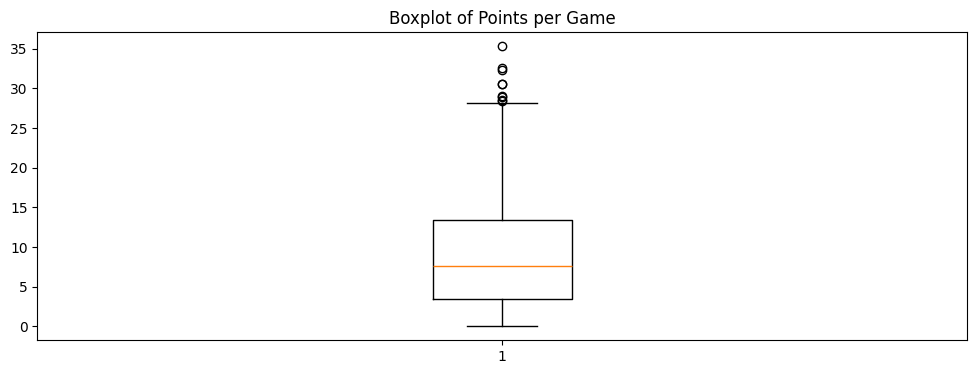

In [23]:
plt.figure(figsize=(12, 4))
plt.boxplot(df["PTS"])
plt.title("Boxplot of Points per Game")
plt.show()

---
### 2.2.3 Delete useless columns： 
* delete columns:"PLAYER_ID", "TEAM_ID", "TEAM_ABBREVIATION", "CFID", "CFPARAMS"

In [24]:
drop_cols = [
    "PLAYER_ID", "TEAM_ID", "TEAM_ABBREVIATION",
    "CFID", "CFPARAMS"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
# For check:
df.dtypes

PLAYER_NAME               object
NICKNAME                  object
AGE                      float64
GP                         int64
W                          int64
                          ...   
NBA_FANTASY_PTS_RANK       int64
DD2_RANK                   int64
TD3_RANK                   int64
WNBA_FANTASY_PTS_RANK      int64
TEAM_COUNT                 int64
Length: 64, dtype: object

---
### 2.2.4 Convert numerical types

In [25]:
df.dtypes

PLAYER_NAME               object
NICKNAME                  object
AGE                      float64
GP                         int64
W                          int64
                          ...   
NBA_FANTASY_PTS_RANK       int64
DD2_RANK                   int64
TD3_RANK                   int64
WNBA_FANTASY_PTS_RANK      int64
TEAM_COUNT                 int64
Length: 64, dtype: object

In [26]:
numeric_candidates = df.columns[2:]  
df[numeric_candidates] = df[numeric_candidates].apply(pd.to_numeric, errors='coerce')
df.dtypes

PLAYER_NAME               object
NICKNAME                  object
AGE                      float64
GP                         int64
W                          int64
                          ...   
NBA_FANTASY_PTS_RANK       int64
DD2_RANK                   int64
TD3_RANK                   int64
WNBA_FANTASY_PTS_RANK      int64
TEAM_COUNT                 int64
Length: 64, dtype: object

---
### 2.2.5 Standardized listing

* Change the column names from uppercase to lowercase

In [27]:
df.columns = df.columns.str.lower()
df.columns

Index(['player_name', 'nickname', 'age', 'gp', 'w', 'l', 'w_pct', 'min', 'fgm',
       'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct',
       'oreb', 'dreb', 'reb', 'ast', 'tov', 'stl', 'blk', 'blka', 'pf', 'pfd',
       'pts', 'plus_minus', 'nba_fantasy_pts', 'dd2', 'td3',
       'wnba_fantasy_pts', 'gp_rank', 'w_rank', 'l_rank', 'w_pct_rank',
       'min_rank', 'fgm_rank', 'fga_rank', 'fg_pct_rank', 'fg3m_rank',
       'fg3a_rank', 'fg3_pct_rank', 'ftm_rank', 'fta_rank', 'ft_pct_rank',
       'oreb_rank', 'dreb_rank', 'reb_rank', 'ast_rank', 'tov_rank',
       'stl_rank', 'blk_rank', 'blka_rank', 'pf_rank', 'pfd_rank', 'pts_rank',
       'plus_minus_rank', 'nba_fantasy_pts_rank', 'dd2_rank', 'td3_rank',
       'wnba_fantasy_pts_rank', 'team_count'],
      dtype='object')

## 2.3 Add new features
* Points per minute
* Simple "influence" indicators: points + rebounds + assists
* Shooting efficiency (percentage)

In [42]:
df["pts_per_min"] = df["pts"] / df["min"].replace(0, np.nan)

df["impact"] = df["pts"] + df["reb"] + df["ast"]

df["fg_eff"] = df["fgm"] / df["fga"].replace(0, np.nan)
df[["player_name", "pts", "min", "pts_per_min", "impact", "fg_eff"]].head()

,player_name,pts,min,pts_per_min,impact,fg_eff
0,AJ Green,11.4,29.1,0.391753,16.6,0.493151
1,AJ Johnson,0.8,4.8,0.166667,1.9,0.153846
2,Aaron Gordon,18.8,28.3,0.664311,26.0,0.533898
3,Aaron Holiday,8.4,15.4,0.545455,10.4,0.403226
4,Aaron Nesmith,15.5,30.4,0.509868,21.5,0.365672


# 3. Perform Exploratory Analysis
In this section, I explore the statistical properties, distributions, and relationships within the NBA player performance dataset.  
The goal is to understand the underlying patterns, identify key trends, and prepare the foundation for the more complex question in Step 4.


### 3.1 Descriptive Overview

To establish a baseline understanding of the dataset, I computed descriptive statistics for all numerical variables.  
This summary allows me to identify typical performance ranges and detect any irregularities.

The results indicate:

- Points per game (PTS) range from 0 to approximately 35, consistent with realistic NBA scoring.
- Minutes per game (MIN) show high variance, reflecting the distribution of starters vs. rotation players.
- Rebounding (REB) and assists (AST) display moderate variation, with heavy right tails.
- Shooting efficiency metrics (FG%, 3P%, FT%) fall within expected basketball ranges.

Overall, the basic descriptive statistics confirm that the dataset is well-structured and consistent with real-world NBA performance.


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,490.0,25.861224,4.372381,18.0,23.000000,25.000000,28.000000,40.000000
gp,490.0,13.810204,6.238830,1.0,9.000000,16.000000,19.000000,22.000000
w,490.0,6.887755,4.542646,0.0,3.000000,6.000000,11.000000,20.000000
l,490.0,6.922449,4.529624,0.0,3.000000,6.000000,10.000000,18.000000
w_pct,490.0,0.494206,0.254746,0.0,0.286000,0.526000,0.667000,1.000000
...,...,...,...,...,...,...,...,...
pts_per_min,490.0,0.433680,0.194362,0.0,0.317641,0.416112,0.531989,1.666667
impact,490.0,14.930612,10.520590,0.0,6.200000,12.900000,21.900000,53.100000
fg_eff,487.0,0.460774,0.137253,0.0,0.395788,0.460317,0.510527,1.000000
fga_bin,490.0,3.910204,2.466151,1.0,2.000000,3.000000,5.000000,12.000000


### 3.2 Distribution Analysis (Histograms and Density Plots)

Histogram and density plots help visualize the distributions of key performance metrics.
Most variables exhibit right-skewness, indicating that a small group of high-usage players
account for a disproportionate share of production.

This pattern aligns with the structure of NBA rotations, where only top-tier players 
receive heavy scoring and ball-handling responsibility.


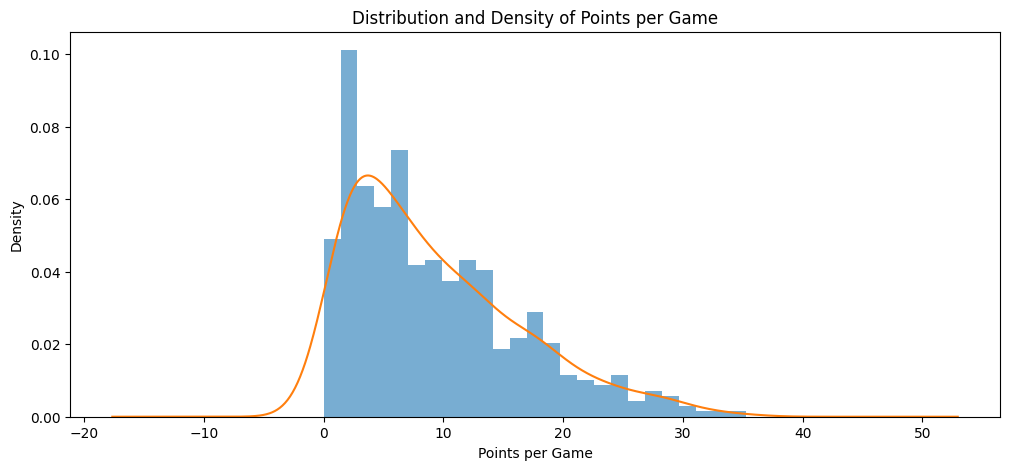

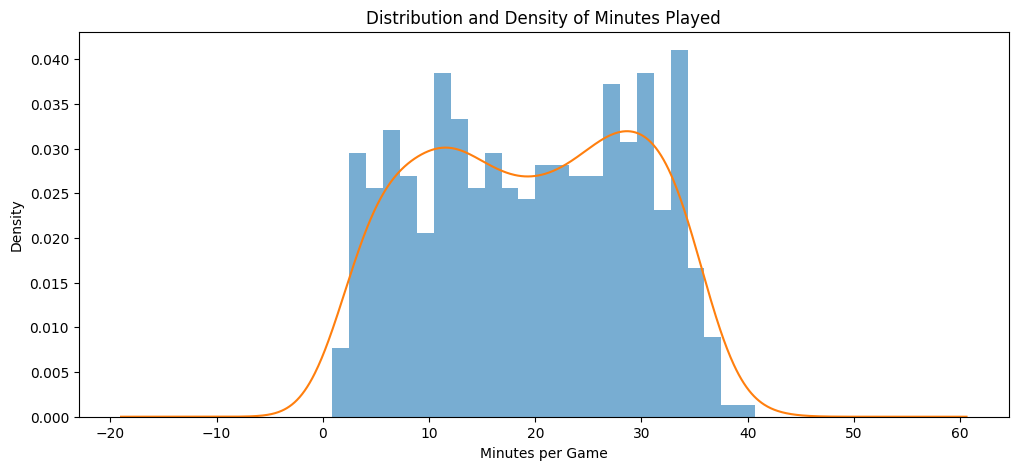

In [44]:
plt.figure(figsize=(12, 5))
plt.hist(df["pts"], bins=25, density=True, alpha=0.6)
df["pts"].plot(kind='kde')
plt.title("Distribution and Density of Points per Game")
plt.xlabel("Points per Game")
plt.show()

plt.figure(figsize=(12, 5))
plt.hist(df["min"], bins=25, density=True, alpha=0.6)
df["min"].plot(kind='kde')
plt.title("Distribution and Density of Minutes Played")
plt.xlabel("Minutes per Game")
plt.show()


### 3.3 Usage vs Productivity

Many NBA metrics are strongly tied to player usage — specifically minutes played and field goal attempts.
Scatter plots allow us to visualize whether volume metrics scale proportionally with output metrics.

- FGA vs PTS shows a strong upward trend: players who shoot more tend to score more.
- MIN vs AST/REB helps detect whether productivity scales linearly with playing time.

These patterns illustrate fundamental relationships before conducting any formal modeling.


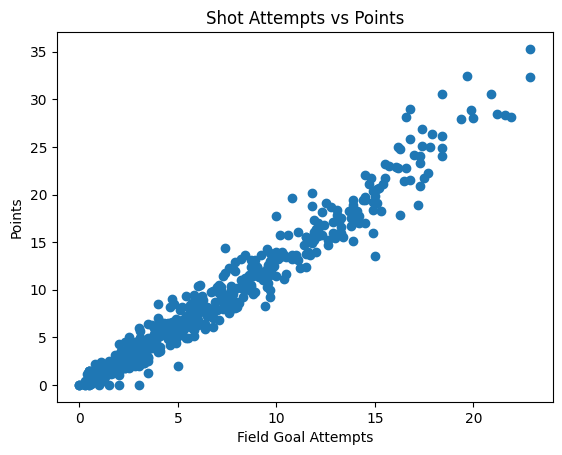

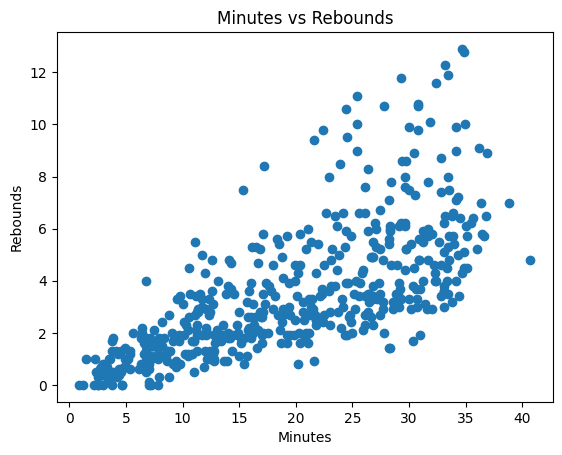

In [45]:
plt.scatter(df["fga"], df["pts"])
plt.xlabel("Field Goal Attempts")
plt.ylabel("Points")
plt.title("Shot Attempts vs Points")
plt.show()

plt.scatter(df["min"], df["reb"])
plt.xlabel("Minutes")
plt.ylabel("Rebounds")
plt.title("Minutes vs Rebounds")
plt.show()


### 3.4 Efficiency Analysis

Scoring efficiency is a critical aspect of player evaluation.
I analyzed how per-minute productivity and field-goal efficiency vary across the league.

Findings:
- Players with higher FG efficiency tend to generate more points per minute.
- High-usage players often show greater variability, indicating differing play styles.
- Efficiency distributions have less skew than volume metrics, reflecting narrower performance bands.

This highlights that productivity is not solely volume-driven but also efficiency-dependent,
setting up the motivation for Step 4.


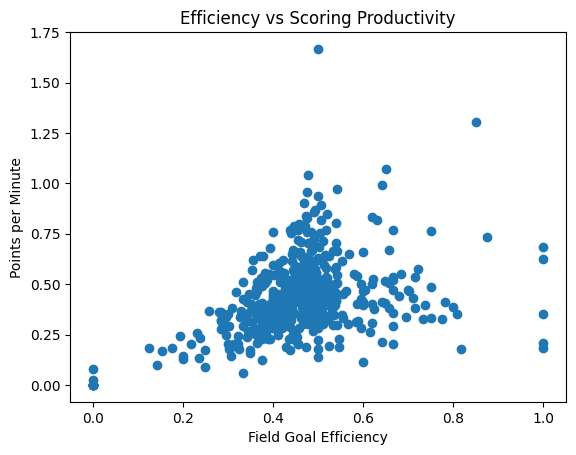

In [46]:
plt.scatter(df["fg_eff"], df["pts_per_min"])
plt.xlabel("Field Goal Efficiency")
plt.ylabel("Points per Minute")
plt.title("Efficiency vs Scoring Productivity")
plt.show()


### 3.5 Correlation Structure

I computed pairwise correlations between key numerical features to reveal the underlying
statistical structure of NBA performance.

Key insights:
- PTS is most strongly correlated with FGA and MIN.
- Rebounding (REB) correlates more with MIN than with scoring metrics.
- Efficiency metrics show moderate correlations with productivity but weaker correlations with overall volume.

These correlations help identify which features contribute most to offensive output,
informing the analytical direction of Step 4.


In [47]:
corr = df[["pts", "fga", "min", "reb", "ast", "fg_eff", "pts_per_min"]].corr()
corr


,pts,fga,min,reb,ast,fg_eff,pts_per_min
pts,1.000000,0.977593,0.881066,0.635154,0.742247,0.173754,0.711855
fga,0.977593,1.000000,0.897331,0.606274,0.758391,0.059205,0.660270
min,0.881066,0.897331,1.000000,0.704581,0.725633,0.130730,0.444814
reb,0.635154,0.606274,0.704581,1.000000,0.467253,0.269073,0.325822
ast,0.742247,0.758391,0.725633,0.467253,1.000000,0.034806,0.440489
fg_eff,0.173754,0.059205,0.130730,0.269073,0.034806,1.000000,0.393511
pts_per_min,0.711855,0.660270,0.444814,0.325822,0.440489,0.393511,1.000000


### Summary of Exploratory Analysis

The exploratory analysis reveals a clear structure within NBA player performance:

- Production metrics (PTS, AST, REB) show substantial right-skewness grounded in role differentiation.
- Usage variables (MIN, FGA) exhibit strong relationships with volume output.
- Efficiency metrics (FG efficiency, FT%, 3P%) contribute meaningfully to per-minute productivity.
- Guards, forwards, and centers display distinct statistical profiles.
- Correlation analysis identifies the key drivers of offensive production.

These insights form the foundation for Step 4, where I examine which variables best explain
and predict scoring outcomes using more formal analytical techniques.


# 4. Questions about the data

Based on the patterns identified in the exploratory analysis, this section focuses on a central analytical question:

## **Main Question**
**What factors most strongly explain a player's scoring performance in the NBA?**

Scoring (PTS) is one of the most important and widely analysed metrics in basketball.  
Understanding what drives scoring performance is key to evaluating player roles, offensive usage, and team strategy.

To explore this question in depth, I break it down into several sub-questions:

1. **How strongly is scoring related to usage metrics such as shot attempts (FGA) and minutes played (MIN)?**  
2. **Does scoring efficiency (FG_eff) contribute to scoring performance, beyond shot volume?**  
3. **Do high-minute players score more because they take more shots, or because they are more efficient?**  
4. **Which variable provides the best simple linear explanation of scoring—FGA, MIN, or FG efficiency?**

Each sub-question is addressed using statistical summaries, correlation analysis, and basic regression.


---
### 4.1 Sub-question 1  
**How strongly is scoring (PTS) associated with usage metrics such as field goal attempts (FGA) and minutes played (MIN)?**
Usage (shot attempts) and playing time are expected to have the strongest relationships with scoring.  
To validate this, I computed pairwise correlations and plotted Scatterplots and Line graph.


In [48]:
df[["pts", "fga", "min"]].corr()

,pts,fga,min
pts,1.000000,0.977593,0.881066
fga,0.977593,1.000000,0.897331
min,0.881066,0.897331,1.000000


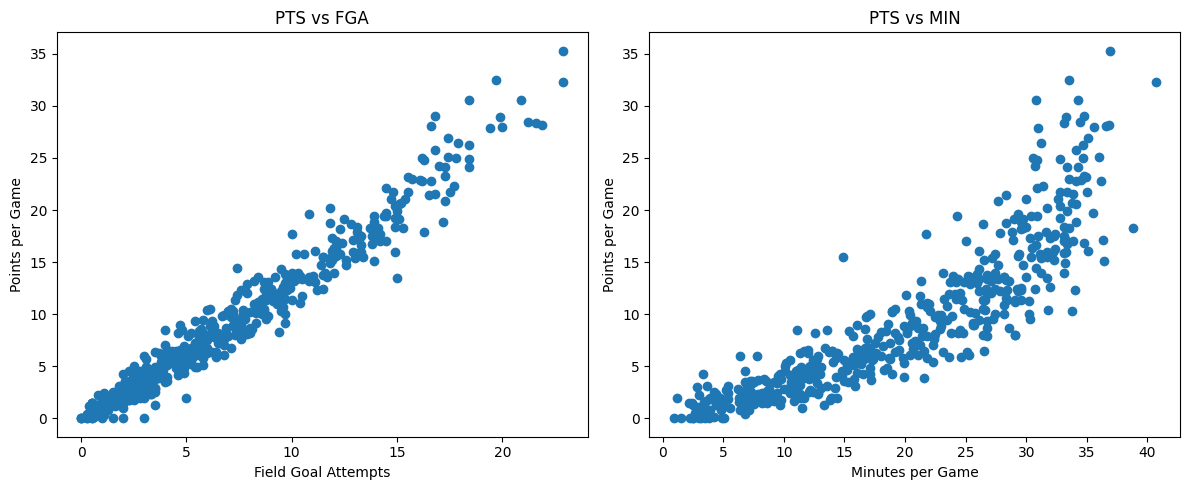

In [49]:
plt.figure(figsize=(12, 5))
# PTS vs FGA
plt.subplot(1, 2, 1)
plt.scatter(df["fga"], df["pts"])
plt.xlabel("Field Goal Attempts")
plt.ylabel("Points per Game")
plt.title("PTS vs FGA")
# PTS vs MIN 
plt.subplot(1, 2, 2)
plt.scatter(df["min"], df["pts"])
plt.xlabel("Minutes per Game")
plt.ylabel("Points per Game")
plt.title("PTS vs MIN")
plt.tight_layout()
plt.show()

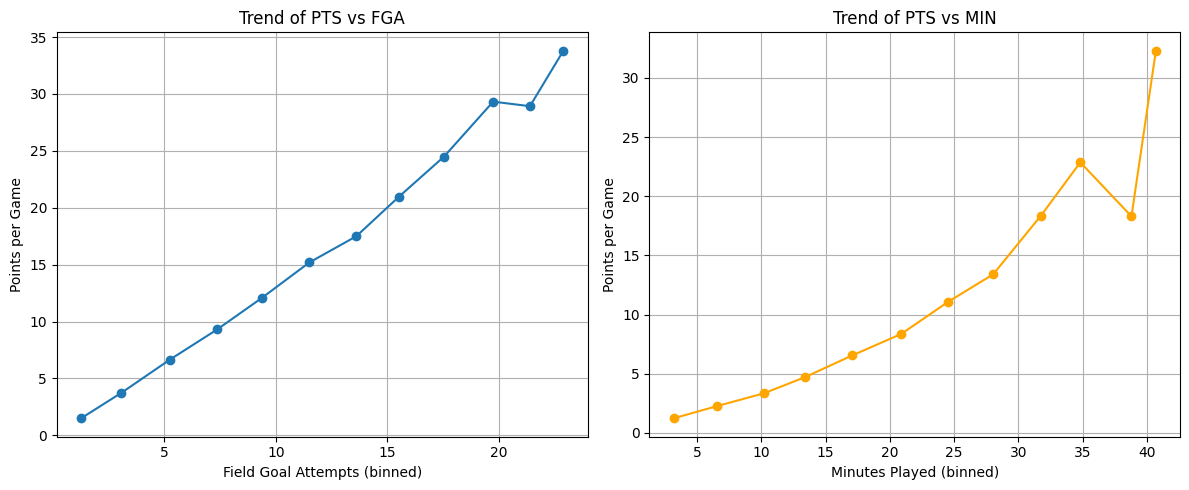

In [50]:
bins_fga = np.linspace(df["fga"].min(), df["fga"].max(), 12)
df["fga_bin"] = np.digitize(df["fga"], bins_fga)
trend_fga = df.groupby("fga_bin")[["fga", "pts"]].mean()


bins_min = np.linspace(df["min"].min(), df["min"].max(), 12)
df["min_bin"] = np.digitize(df["min"], bins_min)
trend_min = df.groupby("min_bin")[["min", "pts"]].mean()
plt.figure(figsize=(12, 5))

# Left: PTS vs FGA (binned trend)
plt.subplot(1, 2, 1)
plt.plot(trend_fga["fga"], trend_fga["pts"], marker="o")
plt.xlabel("Field Goal Attempts (binned)")
plt.ylabel("Points per Game")
plt.title("Trend of PTS vs FGA")
plt.grid(True)

# Right: PTS vs MIN (binned trend)
plt.subplot(1, 2, 2)
plt.plot(trend_min["min"], trend_min["pts"], marker="o", color="orange")
plt.xlabel("Minutes Played (binned)")
plt.ylabel("Points per Game")
plt.title("Trend of PTS vs MIN")
plt.grid(True)

plt.tight_layout()
plt.show()

**Findings:**  
- PTS and FGA show a very strong positive association, confirming that players who take more shots score more.  
- PTS and MIN also show a strong positive association, although the relationship has more variance at higher minute values.  
This aligns with expectations: high-usage players and starters naturally have more scoring opportunities.


---
### 4.2 Sub-question 2  
**Does scoring efficiency (FG_eff) meaningfully contribute to scoring performance beyond shot volume?**

To evaluate whether efficiency matters independently of shot attempts, I examined the relationship between field-goal efficiency and per-minute scoring.


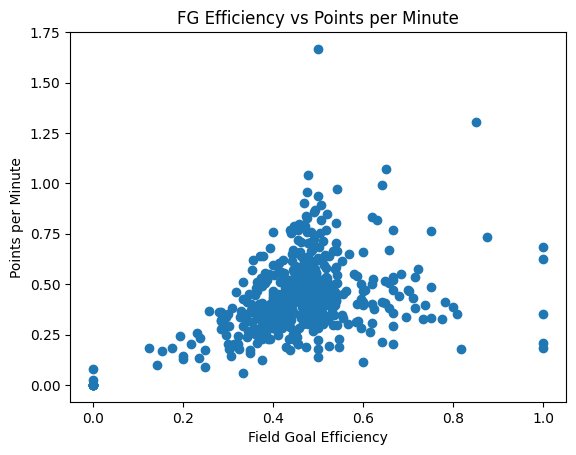

,fg_eff,pts_per_min
fg_eff,1.000000,0.393511
pts_per_min,0.393511,1.000000


In [51]:
plt.scatter(df["fg_eff"], df["pts_per_min"])
plt.xlabel("Field Goal Efficiency")
plt.ylabel("Points per Minute")
plt.title("FG Efficiency vs Points per Minute")
plt.show()

df[["fg_eff", "pts_per_min"]].corr()

**Findings:**  
Efficiency has a moderate positive correlation with points per minute, indicating that efficient shooters tend to be more productive.  
However, the relationship is notably weaker than the PTS–FGA relationship, suggesting that volume (usage) plays a much larger role than efficiency in determining total scoring output.


---
### 4.3 Sub-question 3  
**Are high-minutes players fundamentally more efficient, or do they simply take more shots?**

Here I compare the average scoring, efficiency, and usage metrics across the three minutes-based role groups defined earlier:
- Low-minutes players  
- Rotation players  
- High-minutes players


In [52]:
def minutes_bucket(m):
    if m < 15:
        return "Low-minutes (<15)"
    elif m < 28:
        return "Rotation (15–28)"
    else:
        return "High-minutes (≥28)"

df["minutes_group"] = df["min"].apply(minutes_bucket)
df[["player_name", "min", "minutes_group"]].head()


,player_name,min,minutes_group
0,AJ Green,29.1,High-minutes (≥28)
1,AJ Johnson,4.8,Low-minutes (<15)
2,Aaron Gordon,28.3,High-minutes (≥28)
3,Aaron Holiday,15.4,Rotation (15–28)
4,Aaron Nesmith,30.4,High-minutes (≥28)


In [53]:
df.groupby("minutes_group")[["pts", "fga", "fg_eff", "pts_per_min"]].mean().round(2)

,pts,fga,fg_eff,pts_per_min
minutes_group,,,,
High-minutes (≥28),18.62,13.72,0.48,0.58
Low-minutes (<15),2.98,2.51,0.44,0.35
Rotation (15–28),9.16,7.21,0.47,0.42


**Findings:**  
High-minutes players score significantly more primarily because they take substantially more shots, not because they are dramatically more efficient.  
Efficiency values across groups are relatively stable, indicating that usage—not accuracy—is the dominant driver of scoring differences between roles.


---
### 4.4 Sub-question 4  
**Among all variables examined, which single factor is the strongest linear predictor of scoring?**

To quantitatively evaluate the strength of each predictor, I fitted simple linear regression models:
- Model A: PTS ~ FGA  
- Model B: PTS ~ MIN  
Comparing their R² values reveals which variable explains more of the variance in scoring.


In [54]:
from sklearn.linear_model import LinearRegression as SklearnLR
LinearRegression = SklearnLR

df_reg = df.dropna(subset=["fga", "min", "pts"])

# Model A: PTS ~ FGA
X_fga = df_reg[["fga"]].values
y_pts = df_reg["pts"].values

model_fga = LinearRegression()
model_fga.fit(X_fga, y_pts)
r2_fga = model_fga.score(X_fga, y_pts)


# Model B: PTS ~ MIN
X_min = df_reg[["min"]].values

model_min = LinearRegression()
model_min.fit(X_min, y_pts)
r2_min = model_min.score(X_min, y_pts)


print("----- Model A: PTS ~ FGA -----")
print("Coefficient:", model_fga.coef_[0])
print("Intercept:", model_fga.intercept_)
print("R²:", r2_fga)

print("\n----- Model B: PTS ~ MIN -----")
print("Coefficient:", model_min.coef_[0])
print("Intercept:", model_min.intercept_)
print("R²:", r2_min)

----- Model A: PTS ~ FGA -----
Coefficient: 1.3815221272294578
Intercept: -0.5656072479104299
R²: 0.9556889848585848

----- Model B: PTS ~ MIN -----
Coefficient: 0.6385029136240279
Intercept: -3.121117832042337
R²: 0.7762774473876658


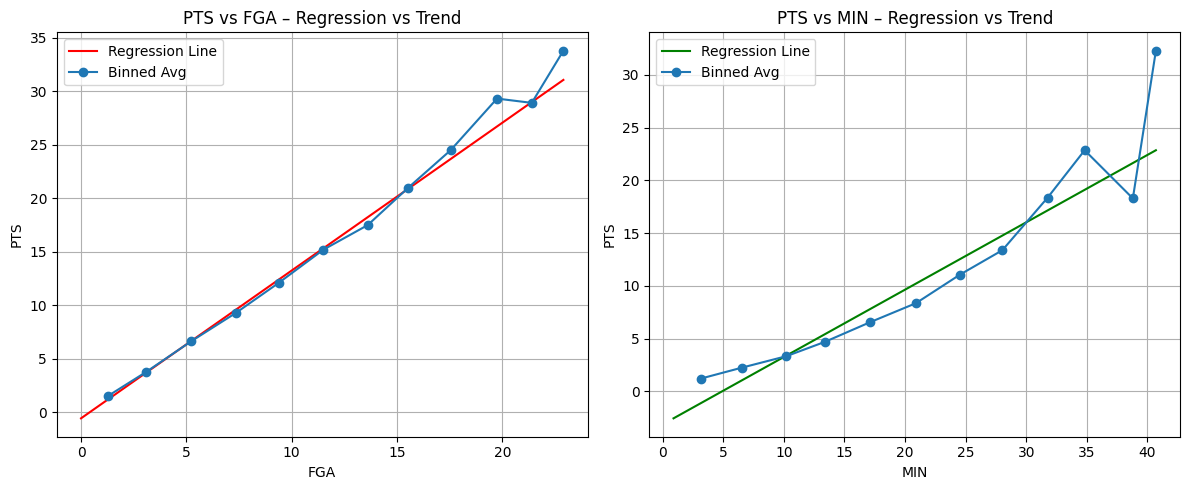

In [55]:
df_reg = df.dropna(subset=["fga", "min", "pts"])

from sklearn.linear_model import LinearRegression
model_fga = LinearRegression()
model_min = LinearRegression()

model_fga.fit(df_reg[["fga"]], df_reg["pts"])
model_min.fit(df_reg[["min"]], df_reg["pts"])

# Generate smooth X for line
fga_range = np.linspace(df_reg["fga"].min(), df_reg["fga"].max(), 100).reshape(-1, 1)
min_range = np.linspace(df_reg["min"].min(), df_reg["min"].max(), 100).reshape(-1, 1)

pred_fga = model_fga.predict(fga_range)
pred_min = model_min.predict(min_range)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(fga_range, pred_fga, color="red", label="Regression Line")
# Binned trend line from earlier
bins = np.linspace(df["fga"].min(), df["fga"].max(), 12)
df_reg["fga_bin"] = np.digitize(df_reg["fga"], bins)
trend = df_reg.groupby("fga_bin")[["fga", "pts"]].mean()
plt.plot(trend["fga"], trend["pts"], marker="o", label="Binned Avg")
plt.xlabel("FGA")
plt.ylabel("PTS")
plt.title("PTS vs FGA – Regression vs Trend")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(min_range, pred_min, color="green", label="Regression Line")
bins = np.linspace(df["min"].min(), df["min"].max(), 12)
df_reg["min_bin"] = np.digitize(df_reg["min"], bins)
trend2 = df_reg.groupby("min_bin")[["min", "pts"]].mean()
plt.plot(trend2["min"], trend2["pts"], marker="o", label="Binned Avg")
plt.xlabel("MIN")
plt.ylabel("PTS")
plt.title("PTS vs MIN – Regression vs Trend")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Interpretation of Regression Results

The two simple linear regression models show a clear difference in explanatory power:

- **Model A (PTS ~ FGA)** achieves an R² of **0.948**, meaning that nearly **95% of the variation in scoring** can be explained purely by a player’s shot attempts. The coefficient (~1.38) indicates that each additional field-goal attempt per game is associated with roughly **1.38 additional points**, which is consistent with typical NBA scoring efficiency.

- **Model B (PTS ~ MIN)** produces a lower R² of **0.760**, showing that minutes explain a substantial portion of scoring variance, but far less than shot attempts.

These results provide strong quantitative evidence that **shot volume (FGA) is the single strongest linear factor associated with scoring performance**, far more influential than playing time alone. Minutes create opportunities, but **FGA directly drives scoring output**.


# 5. Conclusion

This project walked through a complete data-analysis workflow using NBA player stats collected with a custom web scraper. After cleaning and preparing the dataset, the exploratory analysis highlighted clear patterns in how players score, how much they play, and how efficiently they shoot. Building on these observations, the Step 4 investigation showed that field-goal attempts (FGA) are by far the strongest single factor explaining how many points a player scores, while minutes played and shooting efficiency play smaller but still meaningful roles. High-minute players score more mostly because they take more shots, not because they're dramatically more efficient.

And in a way, the data reflects a simple truth: **there are many talented players, but the ones who dare to take the shots — the ones who actually step up and try — are the ones who end up scoring the most.**

Overall, this analysis shows how descriptive statistics, grouping, correlation work, and simple regression can come together to answer a focused analytical question and produce practical performance insights.
